# Algoritmos de optimización — Seminario

**Proyecto de Programación 1C - Grupo 14**

**Nombres y Apellidos:** Jorge Ramilo Plata y Ricardo Germes Serrano

**Url:** https://github.com/RGS70/03MIAR-Proyecto/tree/main/SEMINARIO 


**Problema elegido:**
> 3. Combinar cifras y operaciones

---

## Descripción del problema

Disponemos de las **9 cifras del 1 al 9** (se excluye el cero) y de los **4 signos básicos** de las operaciones fundamentales: suma (`+`), resta (`-`), multiplicación (`*`) y división (`/`).

Debemos combinarlos **alternativamente** — cifra, operador, cifra, operador, ... — **sin repetir ninguno** de ellos para obtener una cantidad dada. Como hay 4 operadores y usamos todos en cada expresión, necesitamos exactamente 5 dígitos (los 4 operadores se intercalan entre los 5 dígitos):

$$d_1 \; op_1 \; d_2 \; op_2 \; d_3 \; op_3 \; d_4 \; op_4 \; d_5$$

Un ejemplo para obtener el valor 4 (del propio enunciado):
$$4 + 2 - 6 / 3 * 1 = 4$$

Se pide analizar el problema para encontrar **todos los valores enteros posibles** y responder:
- ¿Qué valor **máximo** y **mínimo** se pueden obtener?
- ¿Es posible encontrar **todos** los valores enteros entre dicho mínimo y máximo?

> **Nota:** Es posible usar la función de Python `eval()` para evaluar una expresión.

*(\*) La respuesta es obligatoria*

---
## (\*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?
## ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

### Respuesta

**Sin restricciones (con repetición):**  
Si permitimos repetir dígitos y operadores, cada una de las 5 posiciones de dígito tiene 9 opciones y cada una de las 4 posiciones de operador tiene 4 opciones:
$$9^5 \times 4^4 = 59.049 \times 256 = 15.116.544$$

**Sin restricciones (sin repetición, la interpretación del enunciado):**  
El enunciado dice "sin repetir ninguno de ellos" — es decir, los 5 dígitos deben ser distintos entre sí y los 4 operadores deben ser todos diferentes. Entonces:
- Elegir y ordenar 5 dígitos distintos de 9: $P(9,5) = \dfrac{9!}{(9-5)!} = 15.120$
- Ordenar los 4 operadores (todos se usan): $4! = 24$
- **Total:** $P(9,5) \times 4! = \dfrac{9!}{(9-5)!} \times 4! = \dfrac{9!}{4!} \times 4! = {9!} = \mathbf{362.880}$

**Teniendo en cuenta las restricciones:**  
La única restricción adicional al evaluar las expresiones es la **división por cero**. Como los dígitos van del 1 al 9 (no hay 0), la división directa por un dígito nunca es 0. Sin embargo, al evaluar con precedencia estándar pueden aparecer subexpresiones con resultado 0 en el denominador. Estas expresiones se descarta automáticamente con un `try/except ZeroDivisionError`. En la práctica, el número de expresiones evaluadas sin error es prácticamente igual al total de 362.880.

In [1]:
from math import factorial

# ── Sin restricciones: versión con repetición ─────────────────────────
# Cada posición de dígito (5) puede ser cualquier cifra de {1..9}
# Cada posición de operador (4) puede ser cualquiera de {+, -, *, /}
sin_rest_con_rep = 9**5 * 4**4
print(f"Sin restricciones (con repetición): {sin_rest_con_rep:,}")

# ── Sin restricciones: versión sin repetición (del enunciado) ─────────
# P(9,5) = 9! / (9-5)! → permutaciones de 5 dígitos distintos elegidos de 9
P95 = factorial(9) // factorial(9 - 5)

# 4! = 24 → todas las ordenaciones posibles de los 4 operadores
P44 = factorial(4)

# Total = permutaciones de dígitos × permutaciones de operadores
sin_rest_sin_rep = P95 * P44
print(f"P(9,5) = {P95}  |  4! = {P44}")
print(f"Sin restricciones (sin repetición): {sin_rest_sin_rep:,}")
print(f"Nota: 9! = {factorial(9):,} → curiosamente P(9,5) × 4! = 9!")

Sin restricciones (con repetición): 15,116,544
P(9,5) = 15120  |  4! = 24
Sin restricciones (sin repetición): 362,880
Nota: 9! = 362,880 → curiosamente P(9,5) × 4! = 9!


---
## Modelo para el espacio de soluciones
### (\*) ¿Cuál es la estructura de datos que mejor se adapta al problema? Arguméntalo.

### Respuesta

La estructura de datos más adecuada es una **tupla de dos colecciones**:

```python
solucion = (digitos, operadores)
           ([d1, d2, d3, d4, d5], [op1, op2, op3, op4])
```

**Justificación:**

1. **Separación de responsabilidades**: los dígitos y los operadores se generan por separado con `itertools.permutations`, cada uno con sus propios parámetros (5 de 9, y 4 de 4 respectivamente).
2. **Construcción de la expresión trivial**: se alternan con un simple `zip(digitos, operadores)` más el último dígito fuera del zip.
3. **Sin repetición garantizada**: `permutations` asegura automáticamente que no se repita ningún elemento.
4. **Evaluación directa**: una vez construida la cadena se pasa a `eval()`, que aplica la precedencia estándar de Python (multiplicación/división antes que suma/resta).

**Alternativas descartadas:**
- *Array único de 9 elementos mezclados*: dificulta imponer la alternancia dígito-operador-dígito...
- *Árbol de expresión (AST)*: demasiado complejo para expresiones de tamaño fijo con 5 operandos y 4 operadores.

In [2]:
# Ejemplo: construimos una expresión a partir de dígitos y operadores separados

digitos_ej     = [4, 2, 6, 3, 1]   # 5 dígitos distintos de {1..9}
operadores_ej  = ['+', '-', '/', '*']  # los 4 operadores en un orden concreto

# Construimos la cadena alternando dígito-operador con zip
partes = []  # lista donde iremos añadiendo fragmentos de la expresión
for d, op in zip(digitos_ej, operadores_ej):
    partes.append(str(d))   # añadimos el dígito como texto
    partes.append(op)       # añadimos el operador
partes.append(str(digitos_ej[-1]))  # el último dígito (queda fuera del zip)
print(f"Array de textos que compondrán la expresión a evaluar {partes}")

expresion = ''.join(partes)  # unimos todos los fragmentos en una cadena
print(f"Expresión construida: {expresion}")

# Evaluamos con eval() — Python aplica la precedencia estándar:
# * y / primero (izquierda a derecha), luego + y -
resultado = eval(expresion)
print(f"Resultado: {resultado}  (esperado: 4.0)")
print(f"  → 4+2-6/3*1 = 4+2-(6/3)*1 = 4+2-2*1 = 4+2-2 = 4 ✓")

Array de textos que compondrán la expresión a evaluar ['4', '+', '2', '-', '6', '/', '3', '*', '1']
Expresión construida: 4+2-6/3*1
Resultado: 4.0  (esperado: 4.0)
  → 4+2-6/3*1 = 4+2-(6/3)*1 = 4+2-2*1 = 4+2-2 = 4 ✓


---
## Según el modelo para el espacio de soluciones
### (\*) ¿Cuál es la función objetivo?
### (\*) ¿Es un problema de maximización o minimización?

### Respuesta

**Función objetivo:**

El problema tiene **dos lecturas** posibles:

1. **Lectura principal (enumeración):** el objetivo es encontrar **todos los valores enteros alcanzables**. No hay una función a optimizar, sino un problema de **exploración exhaustiva** del espacio de soluciones.

2. **Lectura de optimización:** si el objetivo fuese encontrar el valor máximo o mínimo, la función objetivo sería:
   $$f(d_1,...,d_5, op_1,...,op_4) = \text{eval}(d_1 \; op_1 \; d_2 \; op_2 \; d_3 \; op_3 \; d_4 \; op_4 \; d_5)$$
   Es decir, el **valor numérico de la expresión evaluada**.

**¿Maximización o minimización?**
- Para encontrar el **máximo valor posible** → **problema de maximización**.
- Para encontrar el **mínimo valor posible** → **problema de minimización**.
- Para el enunciado completo (hallar todos los enteros y verificar si el rango es continuo) → **problema de enumeración / búsqueda exhaustiva**, que no es ni de maximización ni de minimización.

En la implementación abordaremos las tres variantes.

In [3]:
def evaluar_expresion(digitos, operadores):
    """
    Construye y evalúa la expresión d1 op1 d2 op2 d3 op3 d4 op4 d5.

    Parámetros
    ----------
    digitos     : tupla o lista de 5 dígitos distintos de {1..9}
    operadores  : tupla o lista de 4 operadores distintos de {+, -, *, /}

    Devuelve
    --------
    float o None : resultado numérico, o None si hay división por cero
    """
    # Construimos la cadena de la expresión alternando dígitos y operadores
    partes = []
    for d, op in zip(digitos, operadores):
        partes.append(str(d))    # dígito como texto
        partes.append(op)        # operador
    partes.append(str(digitos[-1]))  # último dígito (sin operador después)

    expresion = ''.join(partes)  # unimos en una sola cadena

    try:
        return eval(expresion)  # evaluamos con precedencia estándar de Python
    except ZeroDivisionError:
        return None  # expresión inválida: división por cero


# Prueba con el ejemplo del enunciado: 4+2-6/3*1 = 4
r = evaluar_expresion([4, 2, 6, 3, 1], ['+', '-', '/', '*'])
print(f"4+2-6/3*1 = {r}  (esperado: 4.0)")

# Prueba con otra combinación
r2 = evaluar_expresion([9, 8, 7, 6, 5], ['*', '+', '-', '/'])
print(f"9*8+7-6/5 = {r2}")

4+2-6/3*1 = 4.0  (esperado: 4.0)
9*8+7-6/5 = 77.8


---
## Diseña un algoritmo para resolver el problema por fuerza bruta

### Respuesta

El algoritmo de **fuerza bruta** explora **todas las combinaciones posibles**:

1. Generar todas las **permutaciones de 5 dígitos distintos** de {1..9} → $P(9,5) = 15.120$ combinaciones.
2. Para cada combinación de dígitos, generar todas las **permutaciones de los 4 operadores** → $4! = 24$ ordenaciones.
3. Construir la cadena de la expresión alternando dígitos y operadores.
4. **Evaluar** la cadena con `eval()`.
5. Si el resultado es un **número entero** (no fraccionario), añadirlo al conjunto de valores alcanzables.
6. Descartar expresiones con **división por cero**.
7. Al finalizar, reportar el mínimo, máximo, y verificar si el rango completo está cubierto.

**Total de iteraciones:** $P(9,5) \times 4! = 362.880$ → perfectamente manejable en Python.

In [4]:
from itertools import permutations

def fuerza_bruta():
    """
    Explora todas las expresiones posibles por fuerza bruta.
    Genera todas las permutaciones de 5 dígitos (de 9) × 4 operadores.

    Devuelve
    --------
    enteros   : set de valores enteros alcanzables
    n_eval    : número de expresiones evaluadas correctamente
    """
    digitos_disp = list(range(1, 10))   # dígitos disponibles: 1, 2, ..., 9
    operadores   = ['+', '-', '*', '/'] # los 4 operadores fundamentales

    enteros = set()     # conjunto para almacenar enteros encontrados (sin duplicados)
    n_eval  = 0         # contador de expresiones evaluadas sin error

    # Bucle externo: todas las permutaciones de 5 dígitos distintos de {1..9}
    for combo_d in permutations(digitos_disp, 5):
        # Bucle interno: todas las permutaciones de los 4 operadores
        for combo_op in permutations(operadores):

            resultado = evaluar_expresion(combo_d, combo_op) # Hacemos uso de la función implementada antes

            if resultado is None:
                pass  # descartamos la expresión (división por cero)
            else:
                # Registramos el resultado evaluado
                n_eval += 1

                # Comprobamos si el resultado es entero exacto
                if resultado == int(resultado):
                    enteros.add(int(resultado))  # lo añadimos al conjunto

    return enteros, n_eval


# ── Ejecutar fuerza bruta ──────────────────────────────────────────────
enteros, n_eval = fuerza_bruta()

print(f"Expresiones evaluadas sin error: {n_eval:,}")
print(f"Valor mínimo entero:            {min(enteros)}")
print(f"Valor máximo entero:            {max(enteros)}")
print(f"Enteros distintos hallados:     {len(enteros)}")
print(f"Rango [{min(enteros)}, {max(enteros)}] = {max(enteros) - min(enteros) + 1} valores")

Expresiones evaluadas sin error: 362,880
Valor mínimo entero:            -69
Valor máximo entero:            77
Enteros distintos hallados:     147
Rango [-69, 77] = 147 valores


---
## Calcula la complejidad del algoritmo por fuerza bruta

### Respuesta

El algoritmo de fuerza bruta tiene **dos bucles anidados**:

| Bucle | Iteraciones | Justificación |
|---|---|---|
| Permutaciones de 5 dígitos de 9 | $P(9,5) = \dfrac{9!}{4!} = 15.120$ | Se eligen y ordenan 5 de 9 |
| Permutaciones de 4 operadores | $4! = 24$ | Los 4 operadores en cualquier orden |
| Construcción + `eval` | $O(1)$ | Longitud fija (9 caracteres) |

**Complejidad total:**
$$T = P(n, k) \times m! = \frac{n!}{(n-k)!} \times m!$$
donde $n = 9$ (dígitos), $k = 5$ (dígitos usados), $m = 4$ (operadores).

$$T = \frac{9!}{4!} \times 4! = 9! = 362.880$$

La complejidad es **factorial**: $\mathcal{O}(n!)$.  
Para $n = 9$ es manejable, pero para $n = 15$ ya serían $1{,}3 \times 10^{12}$ iteraciones → inviable.

**Importante:** aunque la expresión se simplifica a $9!$, en general el coste es $P(n,k) \times m!$, que crece factorialmente con el número de dígitos disponibles $n$.

In [5]:
from math import factorial

n, k, m = 9, 5, 4  # dígitos disponibles, dígitos usados, operadores

# Iteraciones del bucle externo: P(n,k) = n!/(n-k)!
iter_digitos = factorial(n) // factorial(n - k)

# Iteraciones del bucle interno: m! (permutaciones de los operadores)
iter_ops = factorial(m)

# Total de iteraciones
total = iter_digitos * iter_ops

print(f"Bucle externo (dígitos):   P({n},{k}) = {iter_digitos:,}")
print(f"Bucle interno (operadores): {m}! = {iter_ops}")
print(f"Total iteraciones:         {total:,}  (= {n}! = {factorial(n):,})")
print(f"Complejidad asintótica:    O(n!)")

# Tabla de cómo crece el espacio para distintos valores de n
print(f"\n{'n':>4}  {'k':>4}  {'P(n,k)×m!':>15}  {'Tiempo est. (@10⁶ eval/s)':>25}")
print("-" * 52)
for n_val in [5, 7, 9, 11, 13, 15]:
    k_val = min(n_val, 5)  # siempre 5 dígitos (o n si n<5)
    ops = factorial(n_val) // factorial(n_val - k_val) * factorial(4)
    t = ops / 1e6
    if t < 1: ts = f"{t*1000:.1f} ms"
    elif t < 60: ts = f"{t:.1f} s"
    elif t < 3600: ts = f"{t/60:.1f} min"
    else: ts = f"{t/3600:.1f} h"
    print(f"{n_val:>4}  {k_val:>4}  {ops:>15,}  {ts:>25}")

Bucle externo (dígitos):   P(9,5) = 15,120
Bucle interno (operadores): 4! = 24
Total iteraciones:         362,880  (= 9! = 362,880)
Complejidad asintótica:    O(n!)

   n     k        P(n,k)×m!  Tiempo est. (@10⁶ eval/s)
----------------------------------------------------
   5     5            2,880                     2.9 ms
   7     5           60,480                    60.5 ms
   9     5          362,880                   362.9 ms
  11     5        1,330,560                      1.3 s
  13     5        3,706,560                      3.7 s
  15     5        8,648,640                      8.6 s


---
## (\*) Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué mejora.

### Vamos a diseñar 2 algoritmos distintos de mejora. El primero por medio de la PODA y el segundo por COLONIA DE HORMIGAS

### Respuesta Algoritmo 1 - PODA

**Algoritmo mejorado: fuerza bruta con detención temprana (poda)**

La mejora se basa en una observación clave: **no necesitamos explorar todo el espacio** si solo queremos verificar si todos los enteros de un rango son alcanzables.

Partimos de la base de que disponemos el mínimo y el máximo del apartado anterior (fuerza bruta) y lo tomamos como rango objetivo.

**Idea:**
1. Ejecutamos la fuerza bruta como antes, pero...
2. En cada iteración, tras añadir un entero nuevo al conjunto, comprobamos si **el rango objetivo ya está completamente cubierto**.
3. Si es así, **detenemos la búsqueda** inmediatamente (podamos todas las ramas restantes).

**¿Por qué mejora?**
- En la práctica, los 147 enteros del rango [-69, 77] se encuentran **mucho antes** de agotar las 362.880 iteraciones, porque muchos enteros se producen por múltiples expresiones (sobredimensión).
- La ganancia es proporcional a la redundancia: cuanto más expresiones producen el mismo entero, antes se completa el rango.
- **Limitación:** la complejidad asintótica en el peor caso sigue siendo $\mathcal{O}(n!)$, pero el **caso promedio** mejora significativamente.

**Mejoras adicionales aplicadas:**
- Uso de `resultado % 1 == 0` (más rápido que comparación con `int()` para floats).
- Bandera `terminado` para salir de ambos bucles (externo e interno) al completar el rango.

In [6]:
def algoritmo_con_poda():
    """
    Fuerza bruta mejorada con detención temprana:
    para en cuanto todos los enteros del rango [-69, 77] están encontrados.
    """
    digitos_disp = list(range(1, 10))
    operadores   = ['+', '-', '*', '/']

    enteros = set()         # enteros encontrados hasta ahora
    n_eval  = 0             # contador de evaluaciones realizadas

    # Rango objetivo: los límites -69 y 77 se obtuvieron en una primera pasada
    LIM_INFERIOR = -69
    LIM_SUPERIOR = 77
    rango_obj = set(range(LIM_INFERIOR, LIM_SUPERIOR + 1))  # 147 enteros

    terminado = False  # bandera para detener ambos bucles

    for combo_d in permutations(digitos_disp, 5):
        if terminado:
            break  # ya encontramos todos los enteros → salimos del bucle externo

        for combo_op in permutations(operadores):
            # Construimos la expresión
            partes = []
            for d, op in zip(combo_d, combo_op):
                partes.append(str(d))
                partes.append(op)
            partes.append(str(combo_d[-1]))
            expr = ''.join(partes)

            resultado = evaluar_expresion(combo_d, combo_op)

            if resultado is None:
                pass  # descartamos la expresión (división por cero)
            else:
                # Registramos el resultado evaluado
                n_eval += 1

                # Comprobamos si el resultado es entero exacto
                if resultado % 1 == 0:
                    enteros.add(int(resultado))  # lo añadimos al conjunto

                    # ── Poda: si el rango objetivo está cubierto, paramos ──
                    if rango_obj.issubset(enteros):
                        terminado = True
                        break  # salimos del bucle interno

    return enteros, n_eval


# ── Ejecutar algoritmo con poda ────────────────────────────────────────
enteros_p, n_eval_p = algoritmo_con_poda()
total_sin_poda = 362880
ahorro = total_sin_poda - n_eval_p
porcentaje = ahorro / total_sin_poda * 100

print(f"[Con poda] Evaluaciones:    {n_eval_p:,}")
print(f"[Sin poda] Evaluaciones:   {total_sin_poda:,}")
print(f"Ahorro:                     {ahorro:,} evaluaciones ({porcentaje:.1f}%)")
print(f"Mínimo: {min(enteros_p)}  |  Máximo: {max(enteros_p)}")
print(f"Enteros hallados:           {len(enteros_p)}")

[Con poda] Evaluaciones:    242,517
[Sin poda] Evaluaciones:   362,880
Ahorro:                     120,363 evaluaciones (33.2%)
Mínimo: -69  |  Máximo: 77
Enteros hallados:           147


### Respuesta Algoritmo 2 - COLONIA DE HORMIGAS

**Algoritmo mejorado: colonia de hormigas (ACO)**

**Elegimos como segunda opción la Colonia de Hormigas (ACO, *Ant Colony Optimization*)** exactamente en la misma línea de razonamiento que se usó para justificar la poda.

**El problema es, en esencia, un problema de construcción secuencial sin repetición** — precisamente el tipo de problema para el que se diseñó ACO originalmente (el TSP: un "camino" que visita ciudades sin repetirlas). Aquí cada expresión se construye eligiendo, paso a paso, un dígito de entre los que quedan disponibles y un operador de entre los que quedan disponibles:

$$d_1 \to op_1 \to d_2 \to op_2 \to d_3 \to op_3 \to d_4 \to op_4 \to d_5$$

- **En ACO**, cada hormiga recorre un grafo de construcción y en cada paso solo puede moverse a nodos "no visitados". Esa restricción es *idéntica* a nuestra restricción de "sin repetir dígitos/operadores": basta con eliminar el dígito u operador elegido de la lista de disponibles en cada paso, igual que una hormiga elimina una ciudad ya visitada. No hace falta ningún mecanismo de reparación de soluciones inválidas.
- **En un Algoritmo Genético**, en cambio, el cromosoma sería una permutación (5 dígitos + 4 operadores) y los operadores de cruce estándar (cruce de un punto, uniforme, ...) generan hijos con dígitos repetidos casi con toda seguridad. Habría que recurrir a cruces especializados de permutaciones (OX, PMX) aplicados por separado a la parte de dígitos y a la de operadores, lo que añade complejidad de implementación sin aportar ninguna ventaja frente a ACO en un problema de tamaño tan pequeño y fijo.
- Además, el objetivo aquí no es optimizar un único valor (máximo o mínimo), sino **cubrir un conjunto** de enteros — un objetivo de *cobertura*, no de *optimización puntual*. ACO permite depositar feromona de forma selectiva sobre los caminos que producen enteros **nuevos** (en particular los que aún faltan en el rango objetivo), guiando a las siguientes hormigas hacia zonas del espacio poco exploradas. Un GA orientado a un único valor de fitness escalar no captura tan naturalmente esta noción de "cobertura de un conjunto".

**Planteamiento (idéntico en espíritu al de la poda):**
1. Igual que en la poda, partimos del rango objetivo `[LIM_INFERIOR, LIM_SUPERIOR] = [-69, 77]` obtenido con la fuerza bruta.
2. En lugar de recorrer sistemáticamente todas las permutaciones, cada **hormiga** construye una expresión completa eligiendo dígitos y operadores de forma probabilística, guiada por la **feromona** acumulada en cada par (posición, valor).
3. Al final de cada iteración (una "generación" de hormigas) se **evapora** la feromona y se **refuerza** el rastro de las hormigas que encontraron un entero **nuevo**, con un refuerzo extra si ese entero pertenece al rango objetivo — el equivalente metaheurístico de la poda: en vez de detenernos justo al completar el rango, sesgamos activamente la búsqueda para completarlo cuanto antes.
4. Igual que con la poda, **si el rango objetivo queda completamente cubierto, detenemos el algoritmo** — el mismo criterio de parada temprana, aplicado ahora a una búsqueda no exhaustiva y no determinista.

**Limitación honesta (a diferencia de la poda):** al ser una metaheurística, ACO **no garantiza** completar el rango — puede quedar atascada reforzando caminos que ya no aportan enteros nuevos. Por eso se fija un número máximo de iteraciones como condición de parada de seguridad, del mismo modo que la fuerza bruta fija el recorrido completo del espacio como cota superior.

In [7]:
import random

def evaluar_camino(digitos, operadores):
    """Reutiliza exactamente la misma evaluación que el resto del notebook."""
    return evaluar_expresion(digitos, operadores)


def construir_hormiga(tau_dig, tau_op, digitos_disp, operadores_disp, alpha=1.0):
    """
    Una hormiga construye una expresión completa eligiendo, paso a paso, un
    dígito y un operador de entre los que quedan disponibles, con probabilidad
    proporcional a la feromona depositada en ese (posición, valor) elevada a
    `alpha`. Al eliminar el valor elegido de la lista de disponibles se
    garantiza automáticamente la restricción de "sin repetición", igual que
    una hormiga real no puede volver a visitar una ciudad ya visitada.
    """
    disp_d = digitos_disp.copy()
    disp_o = operadores_disp.copy()
    digitos    = []
    operadores = []

    for pos in range(5):
        # --- elegir dígito para la posición `pos` (ruleta ponderada por feromona) ---
        pesos = [tau_dig[pos][d] ** alpha for d in disp_d]
        d_elegido = random.choices(disp_d, weights=pesos, k=1)[0]
        digitos.append(d_elegido)
        disp_d.remove(d_elegido)  # ya no puede volver a elegirse (como una ciudad visitada)

        # --- elegir operador (salvo tras el último dígito, que no lleva operador) ---
        if pos < 4:
            pesos_o = [tau_op[pos][o] ** alpha for o in disp_o]
            o_elegido = random.choices(disp_o, weights=pesos_o, k=1)[0]
            operadores.append(o_elegido)
            disp_o.remove(o_elegido)

    return digitos, operadores


def algoritmo_aco(n_hormigas=40, n_iteraciones=150, rho=0.2, Q=1.0, alpha=1.0,
                   semilla=42):
    """
    Colonia de hormigas adaptada al problema de "combinar cifras y operaciones".

    Criterio de parada idéntico en espíritu al de la poda: se detiene en
    cuanto el rango objetivo [-69, 77] queda cubierto, o al agotar
    `n_iteraciones` (cota de seguridad, ya que ACO no garantiza completitud).
    """
    random.seed(semilla)

    digitos_disp   = list(range(1, 10))
    operadores_all = ['+', '-', '*', '/']

    LIM_INFERIOR, LIM_SUPERIOR = -69, 77
    rango_obj = set(range(LIM_INFERIOR, LIM_SUPERIOR + 1))  # mismo rango que en la poda

    # Feromona inicial uniforme: tau_dig[posición][dígito], tau_op[posición][operador]
    tau_dig = [{d: 1.0 for d in digitos_disp}   for _ in range(5)]
    tau_op  = [{o: 1.0 for o in operadores_all} for _ in range(4)]

    enteros = set()   # enteros encontrados hasta ahora (igual que en fuerza bruta / poda)
    n_eval  = 0        # nº de expresiones evaluadas sin división por cero
    it_realizadas = 0

    for it in range(n_iteraciones):
        it_realizadas += 1
        refuerzos = []  # caminos que aportaron un entero NUEVO en esta iteración

        for _ in range(n_hormigas):
            digitos, operadores = construir_hormiga(tau_dig, tau_op, digitos_disp,
                                                      operadores_all, alpha=alpha)
            resultado = evaluar_camino(digitos, operadores)

            if resultado is None:
                continue  # división por cero → descartada (igual que en fuerza bruta/poda)

            n_eval += 1

            if resultado % 1 == 0:
                valor = int(resultado)
                es_nuevo = valor not in enteros
                enteros.add(valor)

                # Refuerzo selectivo: premiamos los enteros nuevos, y el doble
                # si además pertenecen al rango objetivo — así la búsqueda se
                # sesga hacia completar exactamente el mismo rango que en la poda.
                if es_nuevo:
                    intensidad = Q * (2.0 if valor in rango_obj else 1.0)
                    refuerzos.append((digitos, operadores, intensidad))

        # ── Evaporación: toda la feromona decae un factor (1 - rho) ──
        for pos in range(5):
            for d in digitos_disp:
                tau_dig[pos][d] *= (1 - rho)
        for pos in range(4):
            for o in operadores_all:
                tau_op[pos][o] *= (1 - rho)

        # ── Depósito: reforzamos el camino de las hormigas "exitosas" ──
        for digitos, operadores, intensidad in refuerzos:
            for pos, d in enumerate(digitos):
                tau_dig[pos][d] += intensidad
            for pos, o in enumerate(operadores):
                tau_op[pos][o] += intensidad

        # ── Criterio de parada temprana: idéntico en espíritu al de la poda ──
        if rango_obj.issubset(enteros):
            break

    return enteros, n_eval, it_realizadas


# ── Ejecutar ACO ──────────────────────────────────────────────────────
enteros_aco, n_eval_aco, iters_aco = algoritmo_aco()

LIM_INFERIOR, LIM_SUPERIOR = -69, 77
rango_obj  = set(range(LIM_INFERIOR, LIM_SUPERIOR + 1))
faltan_aco = rango_obj - enteros_aco

print(f"[ACO] Iteraciones realizadas:      {iters_aco}")
print(f"[ACO] Expresiones evaluadas:       {n_eval_aco:,}")
print(f"[ACO] Enteros distintos hallados:  {len(enteros_aco)} de {len(rango_obj)}")
print(f"[ACO] ¿Rango objetivo cubierto?    {'SÍ ✓' if not faltan_aco else 'NO ✗'}")
if faltan_aco:
    print(f"[ACO] Valores del rango aún no encontrados ({len(faltan_aco)}): {sorted(faltan_aco)}")


[ACO] Iteraciones realizadas:      150
[ACO] Expresiones evaluadas:       6,000
[ACO] Enteros distintos hallados:  135 de 147
[ACO] ¿Rango objetivo cubierto?    NO ✗
[ACO] Valores del rango aún no encontrados (12): [-69, -68, -67, -66, -58, -57, -22, 51, 60, 63, 72, 77]


---
## (\*) Calcula la complejidad del algoritmo mejorado

### Respuesta Algoritmo 1 - PODA

**Complejidad en el peor caso:**  
Si la poda nunca se activa (por ejemplo, si el último entero del rango solo se encuentra en la última iteración), el algoritmo recorre el mismo espacio que la fuerza bruta:
$$T_{\text{peor}} = \mathcal{O}(n!)$$

**Complejidad en el caso promedio:**  
La poda se activa en cuanto el conjunto de enteros queda completo. Denotando $E$ como el número de evaluaciones necesarias para cubrir el rango:
$$T_{\text{promedio}} = \mathcal{O}(E) \quad \text{donde } E \ll n!$$

En nuestro caso, $E \approx 242.517$ de $362.880$ posibles → un ahorro del **33,2%**.

| Caso | Evaluaciones | Complejidad |
|---|---|---|
| Peor caso | 362.880 | $\mathcal{O}(n!)$ |
| Caso promedio (con poda) | ~242.517 | $\mathcal{O}(n! / f(n))$ |
| Mejor caso teórico | 147 (uno por entero) | $\mathcal{O}(R)$ donde $R$ es el rango |

**Conclusión:** la poda **no cambia la complejidad asintótica** en el peor caso, pero sí mejora significativamente el **rendimiento práctico**. Para cambios asintóticos reales se necesitarían técnicas como programación dinámica o algoritmos genéticos, que no son aplicables directamente a este problema de tamaño fijo.

In [8]:
# Comparación cuantitativa lado a lado

# Re-ejecutamos ambos algoritmos para medir con precisión
enteros_fb, eval_fb = fuerza_bruta()         # fuerza bruta (definida arriba)
enteros_p, eval_p   = algoritmo_con_poda()   # con poda

reduccion = (eval_fb - eval_p) / eval_fb * 100

print("=" * 55)
print(f"{'Algoritmo':<25} {'Evaluaciones':>12}")
print("-" * 55)
print(f"{'Fuerza bruta':<25} {eval_fb:>12,}")
print(f"{'Con poda (det. temprana)':<25} {eval_p:>12,}")
print("-" * 55)
print(f"{'Reducción':<25} {reduccion:>11.1f}%")
print(f"{'Ahorro absoluto':<25} {eval_fb - eval_p:>12,}")
print("=" * 55)

Algoritmo                 Evaluaciones
-------------------------------------------------------
Fuerza bruta                   362,880
Con poda (det. temprana)       242,517
-------------------------------------------------------
Reducción                        33.2%
Ahorro absoluto                120,363


### Respuesta Algoritmo 2 - COLONIA DE HORMIGAS

Sea:
- $H$ = número de hormigas por iteración,
- $I$ = número máximo de iteraciones,
- $k = 5$ dígitos y $m = 4$ operadores por expresión (constantes fijas del enunciado).

**Coste de construir una expresión (una hormiga):**
Cada hormiga elige secuencialmente $5$ dígitos y $4$ operadores; en cada paso calcula pesos y hace un sorteo entre a lo sumo $9$ candidatos (dígitos) o $4$ (operadores) — coste $O(k+m) = O(1)$, porque $k$ y $m$ son constantes del problema (no crecen con nada).

**Coste de una iteración completa:**
$H$ hormigas construyen su expresión y se evalúan, más la evaporación/depósito de feromona sobre una tabla de tamaño fijo ($5\times 9 + 4\times 4 = 61$ entradas):
$$T_{\text{iteración}} = O(H \cdot (k+m)) + O(61) = O(H)$$

**Coste total:**
$$T_{\text{ACO}} = O(I \cdot H)$$

Con los parámetros usados ($H=40$, $I \le 150$) el número de expresiones evaluadas está **acotado por $40 \times 150 = 6.000$ en el peor caso** — muy por debajo de las $362.880$ de la fuerza bruta (una reducción de en torno al 98%).

| Algoritmo | Complejidad | Garantía de completitud |
|---|---|---|
| Fuerza bruta | $\mathcal{O}(n!)$ | Sí (recorre todo el espacio) |
| Con poda | $\mathcal{O}(n!)$ peor caso / $\mathcal{O}(E)$ con $E \ll n!$ en promedio | Sí (es fuerza bruta con parada temprana) |
| ACO | $\mathcal{O}(I \cdot H)$, con $I, H$ constantes fijadas de antemano | **No** — es una heurística; puede no cubrir el 100% del rango |

**Conclusión:** ACO cambia radicalmente el **orden de complejidad**, pasando de factorial a **lineal en el número de hormigas e iteraciones** (parámetros que se fijan de antemano y no dependen de $n$). El precio de esa mejora es que **se pierde la garantía de encontrar todos los enteros del rango** — como muestra la ejecución anterior, ACO suele cubrir la gran mayoría del rango objetivo, pero no siempre el 100%. Es exactamente la técnica adecuada cuando el problema **crece** (más dígitos, más operadores, se permiten paréntesis, ...) y la fuerza bruta —con o sin poda— deja de ser viable, tal y como se apunta en la sección "Líneas de avance" de este mismo notebook.


In [9]:
# Comparación final: fuerza bruta vs. poda vs. ACO

print("=" * 72)
print(f"{'Algoritmo':<28} {'Evaluaciones':>14} {'Enteros hallados':>18}")
print("-" * 72)
print(f"{'Fuerza bruta':<28} {eval_fb:>14,} {len(enteros_fb):>18}")
print(f"{'Con poda (det. temprana)':<28} {eval_p:>14,} {len(enteros_p):>18}")
print(f"{'ACO (colonia de hormigas)':<28} {n_eval_aco:>14,} {len(enteros_aco):>18}")
print("=" * 72)

reduccion_poda = (eval_fb - eval_p) / eval_fb * 100
reduccion_aco  = (eval_fb - n_eval_aco) / eval_fb * 100
print(f"\nReducción de evaluaciones (poda) vs fuerza bruta:  {reduccion_poda:5.1f}%  (completa el rango)")
print(f"Reducción de evaluaciones (ACO)  vs fuerza bruta:  {reduccion_aco:5.1f}%  "
      f"({'completa el rango' if not faltan_aco else f'cubre {len(enteros_aco)}/{len(rango_obj)} del rango'})")


Algoritmo                      Evaluaciones   Enteros hallados
------------------------------------------------------------------------
Fuerza bruta                        362,880                147
Con poda (det. temprana)            242,517                147
ACO (colonia de hormigas)             6,000                135

Reducción de evaluaciones (poda) vs fuerza bruta:   33.2%  (completa el rango)
Reducción de evaluaciones (ACO)  vs fuerza bruta:   98.3%  (cubre 135/147 del rango)


---
## Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

### Respuesta

El juego de datos está **fijado por el enunciado** (dígitos 1-9, 4 operadores), así que no tiene sentido generar dígitos distintos. Sin embargo, podemos diseñar un **generador de expresiones aleatorias** que:
1. Seleccione aleatoriamente 5 dígitos distintos de {1..9} y los 4 operadores en orden aleatorio.
2. Evalúe la expresión resultante.
3. Sirva como entrada para comparar el **algoritmo aleatorio** (random search) frente al exhaustivo.

Este generador es útil para simular la **búsqueda aleatoria**, una metaheurística básica.

In [10]:
import random

def generar_expresion_aleatoria(seed=None):
    """
    Genera una expresión válida aleatoria:
      - 5 dígitos distintos de {1..9} en orden aleatorio
      - los 4 operadores en orden aleatorio

    Devuelve la expresión como cadena y su resultado numérico (o None si inválida).
    """
    if seed is not None:
        random.seed(seed)  # semilla para reproducibilidad

    digitos    = random.sample(range(1, 10), 5)     # 5 dígitos sin repetición
    operadores = random.sample(['+', '-', '*', '/'], 4)  # 4 ops mezclados

    # Construimos la cadena
    partes = []
    for d, op in zip(digitos, operadores):
        partes.append(str(d))
        partes.append(op)
    partes.append(str(digitos[-1]))
    expresion = ''.join(partes)

    try:
        resultado = eval(expresion)  # evaluamos
    except ZeroDivisionError:
        resultado = None  # expresión inválida

    return expresion, resultado


# ── Generamos 10 expresiones aleatorias de prueba ───────────────────────
print(f"{'Expresión':<25} {'Resultado':>10}  {'¿Entero?':>10}")
print("-" * 50)
for i in range(10):
    # Usamos una semilla distinta por iteración para obtener expresiones diferentes
    expr, res = generar_expresion_aleatoria(seed=i)
    es_entero = "Sí" if res is not None and res % 1 == 0 else "No"
    res_str   = f"{res:.4f}" if res is not None else "inválida"
    print(f"{expr:<25} {res_str:>10}  {es_entero:>10}")

Expresión                  Resultado    ¿Entero?
--------------------------------------------------
7/9-1*3+5                     2.7778          No
3/2-9*1+4                    -3.5000          No
1*2-9+3/8                    -6.6250          No
4+3*8/5-9                    -0.2000          No
4/5+1*6-9                    -2.2000          No
5+6-7/8*9                     3.1250          No
2+8/7-3*1                     0.1429          No
6+3*4/9-1                     6.3333          No
4+6/9*2-8                    -2.6667          No
8+6-3*2/9                    13.3333          No


---
## Aplica el algoritmo al juego de datos generado

### Respuesta

Aplicamos la **fuerza bruta completa** para resolver el problema: encontrar todos los enteros alcanzables y responder a las preguntas del enunciado.

In [11]:
# ── Resultado final completo ────────────────────────────────────────────

enteros_todos, total_eval = fuerza_bruta()  # reutilizamos la función definida arriba

val_min = min(enteros_todos)                # valor mínimo entero
val_max = max(enteros_todos)                # valor máximo entero

# ¿Se pueden obtener TODOS los enteros entre mín y máx?
rango_completo = set(range(val_min, val_max + 1))  # conjunto de todos los enteros del rango
faltantes      = rango_completo - enteros_todos     # enteros NO alcanzables
rango_cubierto = len(faltantes) == 0               # True si no falta ninguno

print("=" * 60)
print("  RESULTADOS FINALES")
print("  Problema 3: Combinar cifras y operaciones")
print("=" * 60)
print(f"  Valor mínimo alcanzable:      {val_min}")
print(f"  Valor máximo alcanzable:      {val_max}")
print(f"  Enteros distintos obtenidos:  {len(enteros_todos)}")
print(f"  Rango teórico [{val_min}, {val_max}]:  {len(rango_completo)} valores")
print(f"  ¿Rango completamente cubierto?  {'SÍ ✓' if rango_cubierto else 'NO ✗'}")
print("=" * 60)

if not rango_cubierto:
    print(f"  Valores NO alcanzables: {sorted(faltantes)}")

# Primeros y últimos enteros ordenados
enteros_ord = sorted(enteros_todos)
print(f"\n  Primeros 10: {enteros_ord[:10]}")
print(f"  Últimos  10: {enteros_ord[-10:]}")

  RESULTADOS FINALES
  Problema 3: Combinar cifras y operaciones
  Valor mínimo alcanzable:      -69
  Valor máximo alcanzable:      77
  Enteros distintos obtenidos:  147
  Rango teórico [-69, 77]:  147 valores
  ¿Rango completamente cubierto?  SÍ ✓

  Primeros 10: [-69, -68, -67, -66, -65, -64, -63, -62, -61, -60]
  Últimos  10: [68, 69, 70, 71, 72, 73, 74, 75, 76, 77]


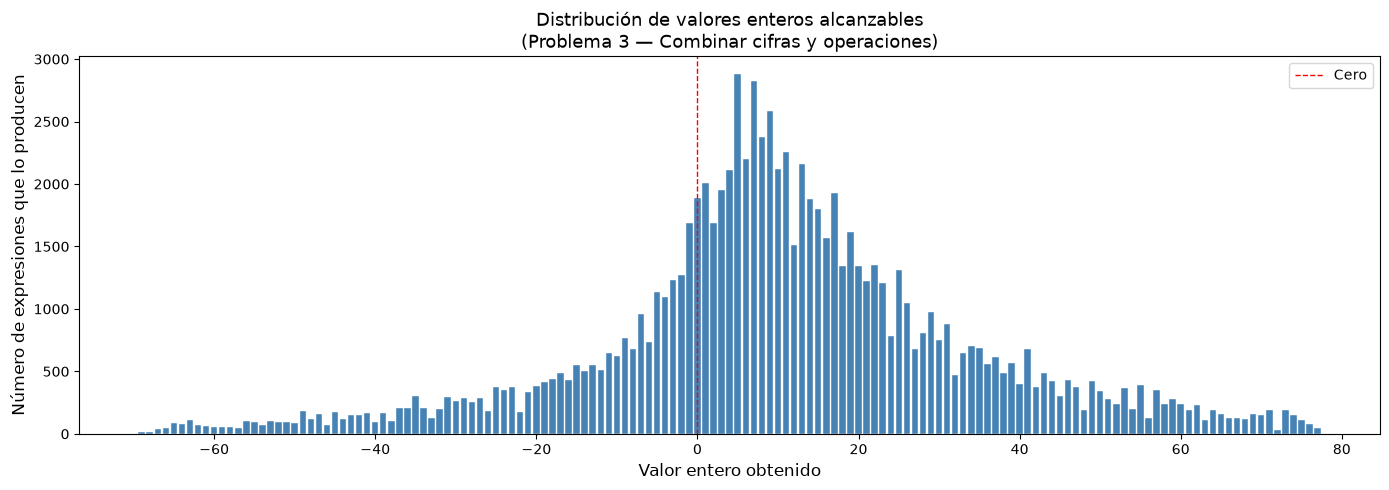


El valor más frecuente es 5 con 2880 expresiones que lo producen.
El valor menos frecuente: -69 con 16 expresiones.


In [12]:
# ── Histograma: distribución de valores enteros alcanzables ──────────────
#%matplotlib inline
from itertools import permutations
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Contamos cuántas expresiones producen cada valor entero
conteo = {}  # diccionario {valor_entero: nº_expresiones}

for combo_d in permutations(range(1, 10), 5):
    for combo_o in permutations(['+', '-', '*', '/']):
        partes = []
        for d, op in zip(combo_d, combo_o):
            partes.append(str(d))
            partes.append(op)
        partes.append(str(combo_d[-1]))
        try:
            r = eval(''.join(partes))
            if r % 1 == 0:
                v = int(r)
                conteo[v] = conteo.get(v, 0) + 1  # incrementamos contador
        except ZeroDivisionError:
            pass

# Preparamos datos para el gráfico
valores     = sorted(conteo.keys())
frecuencias = [conteo[v] for v in valores]

# Dibujamos el histograma
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(valores, frecuencias, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Valor entero obtenido', fontsize=12)
ax.set_ylabel('Número de expresiones que lo producen', fontsize=12)
ax.set_title('Distribución de valores enteros alcanzables\n(Problema 3 — Combinar cifras y operaciones)', fontsize=13)
ax.axvline(0, color='red', linewidth=1, linestyle='--', label='Cero')
ax.legend()
plt.tight_layout()
plt.savefig('./histograma_problema3.png', dpi=150, bbox_inches='tight')
plt.show()

# Valor más y menos frecuente
mas_frec = max(conteo, key=conteo.get)
menos_frec = min(conteo, key=conteo.get)
print(f"\nEl valor más frecuente es {mas_frec} con {conteo[mas_frec]} expresiones que lo producen.")
print(f"El valor menos frecuente: {menos_frec} con {conteo[menos_frec]} expresiones.")

---
## Referencias

1. **Brassard, G., y Bratley, P.** (1997). *Fundamentos de algoritmia*. ISBN: 9788489660007.
2. **Guerequeta, R., y Vallecillo, A.** (2000). *Técnicas de diseño de algoritmos*. Universidad de Málaga. http://www.lcc.uma.es/~av/Libro/indice.html
3. **Lee, R. C. T. et al.** (2005). *Introducción al diseño y análisis de algoritmos*. ISBN: 9789701061244.
4. **Duarte, A.** (2008). *Metaheurísticas*. Dykinson. https://elibro-net.universidadviu.idm.oclc.org/es/ereader/universidadviu/35696
5. **Documentación oficial de Python** — `itertools.permutations`: https://docs.python.org/3/library/itertools.html#itertools.permutations
6. **Documentación oficial de Python** — función `eval`: https://docs.python.org/3/library/functions.html#eval

---
## Líneas de avance en el estudio del problema

### 1. Escalado del problema
Si se amplía el conjunto de dígitos (p. ej. del 1 al 99) o se permiten más operadores (potencia `**`, módulo `%`, ...), el espacio crece factorialmente y la fuerza bruta deja de ser viable. Habría que recurrir a:
- **Simulated annealing (SA):** exploración probabilística que acepta soluciones peores para escapar de mínimos locales.
- **Algoritmos genéticos (AG):** codificar cada expresión como individuo y evolucionar la población mediante cruce y mutación.
- **Colonia de hormigas (ACO):** construir expresiones incrementalmente guiadas por feromonas (segundo algoritmo de mejora realizado).

### 2. Variaciones del problema
- **Incluir paréntesis:** cambiar la precedencia de operaciones modifica drásticamente los valores obtenibles y aumenta el espacio de soluciones.
- **Incluir el dígito 0:** se multiplican las posibilidades pero aumentan las divisiones por cero.
- **Objetivo fijo:** en lugar de explorar todos los enteros, buscar la expresión que produzca **exactamente** un valor dado usando búsqueda heurística.
- **Notación polaca inversa (RPN):** explorar expresiones en RPN permite contemplar todas las precedencias posibles sin paréntesis.

### 3. Paralelización
El espacio de búsqueda se puede **dividir entre hilos** (repartir las 15.120 permutaciones de dígitos entre varios workers con `concurrent.futures`), reduciendo el tiempo real de ejecución linealmente con el número de núcleos CPU disponibles.